# Credit Card Fraud Detection USING ML

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,precision_recall_curve,auc

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

In [ ]:
df = pd.read_csv("/content/creditcard_5000.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,121958,0.486036,0.101723,-0.815592,-1.721047,-0.002736,-0.843590,0.354177,-0.545922,1.117118,-1.304598,-1.791962,1.010769,-0.529630,-0.191104,1.873125,-1.273362,0.701598,-0.050639,-1.487236,1.198583,0.088659,0.809815,0.139065,0.675980,1.365122,-1.952076,0.139163,-1.452492,1587.59,0
1,146867,-1.547304,1.498012,-0.349863,-0.982416,-0.394599,-0.474763,0.483706,-1.404541,0.599804,0.312358,1.405156,0.346336,0.637483,-0.294222,-0.683126,0.399356,-0.427517,-1.214567,0.078156,-1.032014,-2.018395,1.165325,-1.998137,-0.797603,-0.028983,-0.389299,-0.235003,-0.179763,73.94,0
2,131932,1.082691,-0.312836,0.649581,-0.430415,0.396706,1.254656,0.227148,-0.893522,-1.276280,-0.344133,1.073352,1.122993,-1.982815,-0.077006,-0.181086,-0.691824,0.409904,1.311325,-0.857514,-0.305719,0.299506,0.014265,-0.239139,-1.432304,1.484852,0.707765,2.008292,-1.269684,1838.56,0
3,103694,-0.471125,1.030919,-0.342718,1.368189,-0.193658,1.796147,-0.616184,-0.640656,0.447960,1.084443,0.540564,-1.479820,1.795035,1.520497,0.256253,0.250198,-0.669058,-0.033467,-0.441874,0.239591,0.610152,-0.232129,1.306864,0.490955,0.839080,-0.166274,1.483266,-0.477960,77.23,0
4,119879,-0.093636,-0.288063,1.078426,0.901144,-0.085176,-1.264686,-0.201492,-0.196552,1.047670,0.814979,-2.004258,-0.317665,1.238833,0.843087,-1.324014,-0.747517,0.666364,-0.213865,0.133626,-2.102505,-0.459552,-0.070654,-1.066149,0.447087,-0.418308,0.173153,-0.608651,-2.035171,33.79,0


(5000, 31)
Class
0    4914
1      86
Name: count, dtype: int64


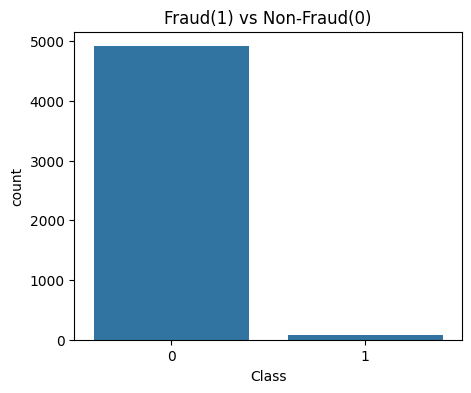

In [ ]:
print(df.shape)
print(df["Class"].value_counts())


plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Class")
plt.title("Fraud(1) vs Non-Fraud(0)")
plt.show()


#Split Features & Labels


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split


In [ ]:
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

 # Standardize Amount & Time


In [ ]:
scaler = StandardScaler()
X_train[['Amount','Time']] = scaler.fit_transform(X_train[['Amount','Time']])
X_test[['Amount','Time']] = scaler.transform(X_test[['Amount','Time']])

#Handle Imbalance with SMOTE

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res =sm.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Class
0    3931
1      69
Name: count, dtype: int64
After SMOTE: Class
0    3931
1    3931
Name: count, dtype: int64


# Train XGBoost Fraud Detector

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, ...)

 # Predictions & Performance


In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       983
           1       0.00      0.00      0.00        17

    accuracy                           0.97      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.97      0.97      0.97      1000



# confusion Matrix

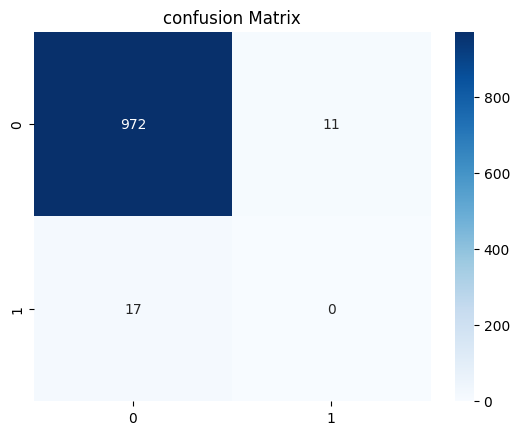

In [ ]:
cm =confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("confusion Matrix")
plt.show()

# PR curve +PR AUC

PR-AUC: 0.01600701655313942


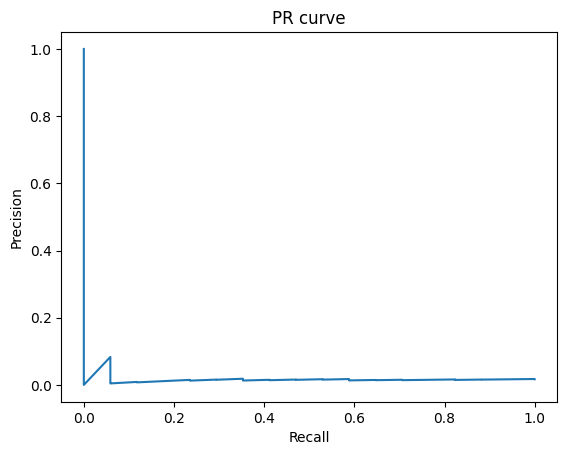

In [ ]:
# Precision-Recall AUC (very important for fraud)
precision,recall,thresholds =precision_recall_curve(y_test,y_proba)
pr_auc = auc(recall,precision)
print("PR-AUC:", pr_auc)

plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR curve")
plt.show()

# ROC-AUC

In [ ]:
rocauc =roc_auc_score(y_test,y_proba)
rocauc

np.float64(0.4369576925378493)

# SHAP Explainability (Why a Transaction Is Fraud)


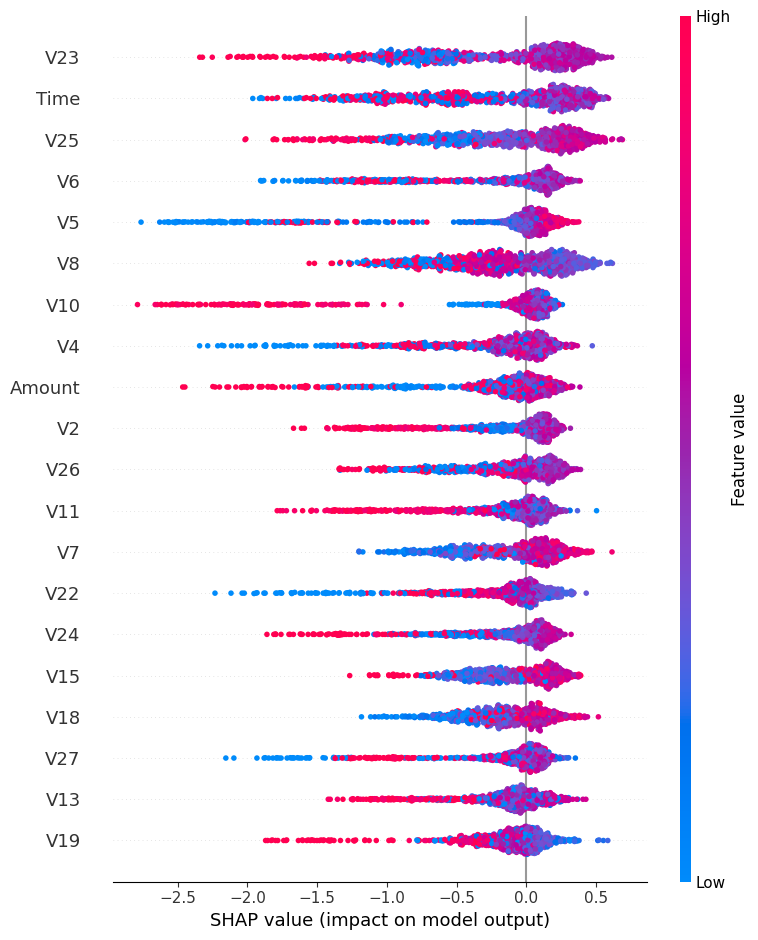

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

#  Try New Transaction (Manual Input)

In [ ]:
sample = X_test.iloc[20:21]   # pick any row or make your own
proba = model.predict_proba(sample)[0][1]
proba


np.float32(0.0014410773)